

# Smoker Classification Model
**Objective:**

In this lab, I worked with an insurance dataset where my goal was not just to make a prediction, but to develop the best possible model for prediction.

## Dataset Description

The dataset contains the following features:

*   **age**: Age of the primary beneficiary.
*   **sex**: Gender of the insurance contractor (female or male).
*   **bmi**: Body mass index, an objective measure of body weight (kg/m²), helping to understand body weight relative to height. An ideal BMI range is between 18.5 and 24.9.
*   **children**: Number of children or dependents covered by the health insurance.
*   **smoker**: Whether the individual is a smoker or not.
*   **region**: The region where the beneficiary resides in the US, including northeast, southeast, southwest, and northwest.
*   **charges**: The individual medical costs billed by the health insurance company.

---



## 1. Data Loading

#### Import necessary python modules

We will need the following libraries:
 - Numpy — for scientific computing (e.g., linear algebra (vectors & matrices)).
 - Pandas — providing high-performance, easy-to-use data reading, manipulation, and analysis.
 - Matplotlib — plotting & visualization.
 - scikit-learn — a tool for data mining and machine learning models.
 - joblib - used to save and reload trained machine learning models without retraining.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


import joblib

#### Read & visualize data


In [2]:
# read CSV file in Pandas
data = pd.read_csv('insurance.csv')

# display first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Exploratory Data Analysis



In [3]:
# get the number of rows and columns
rows, columns = data.shape
print('There are {} rows and {} columns.'.format(rows, columns))

There are 1338 rows and 7 columns.


Using the function **info()**, we can check:
 - data types (int, float, or object (e.g., string))
 - missing values
 - memory usage
 - number of rows and columns

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1335 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Using the function **describe()**, we can check the mean, standard deviation, maximum, and minimum of each numerical feature (column)

In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1335.000000,1338.000000,1338.000000
mean,39.207025,30.661423,1.094918,13270.422265
std,14.049960,6.101038,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.302500,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.687500,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


First, let's see how many smokers vs non-smokers we have.

In [6]:
# select smokers
smokers = data.loc[data['smoker'] == 'yes']

# select non smokers
non_smokers = data.loc[data['smoker'] == 'no']

print('There are {} smokers and {} non-smokers.'.format(smokers.shape[0], non_smokers.shape[0]))

There are 274 smokers and 1064 non-smokers.


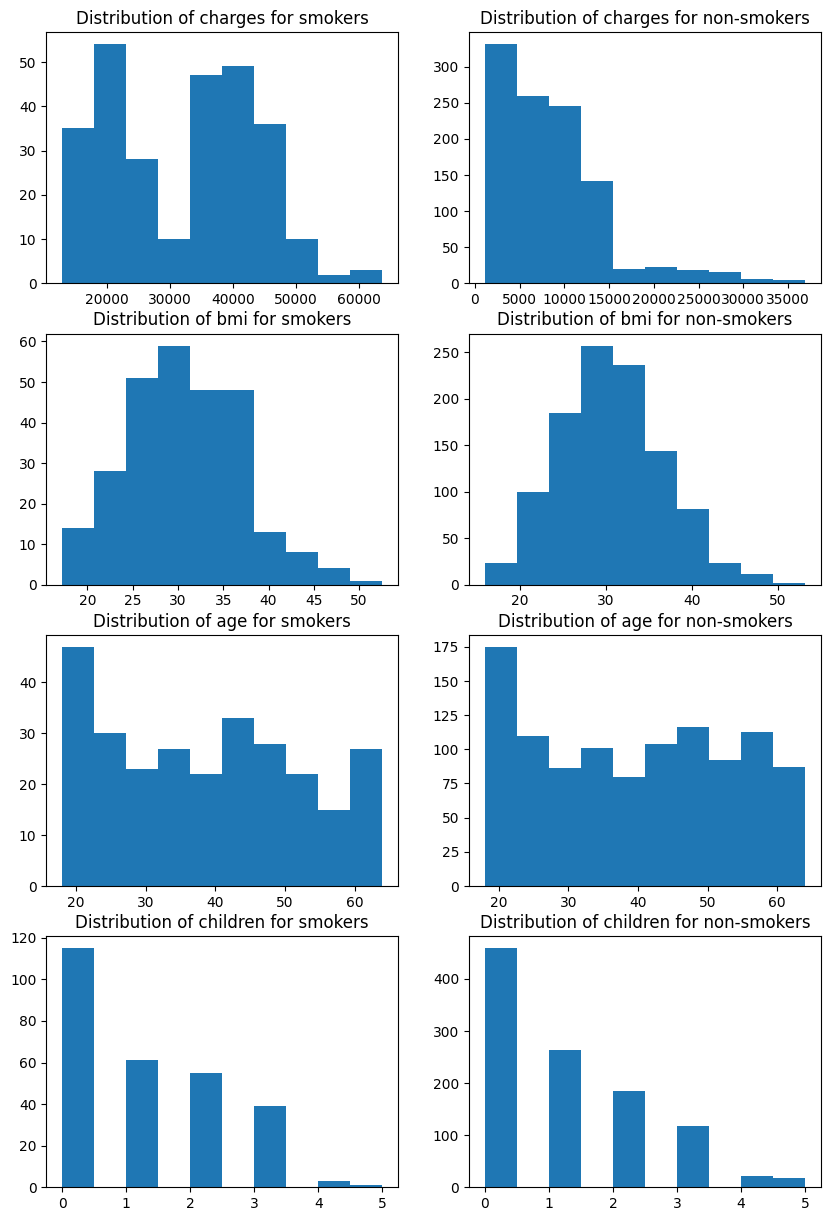

In [7]:
numerical_features = ['charges', 'bmi', 'age', 'children']

subplot_number = 421
fig = plt.figure(figsize=(10,15))

for f in numerical_features:

  ax = fig.add_subplot(subplot_number)
  subplot_number += 1
  ax.hist(smokers[f])
  ax.set_title('Distribution of ' + f + ' for smokers')

  ax = fig.add_subplot(subplot_number)
  subplot_number += 1
  ax.hist(non_smokers[f])
  ax.set_title('Distribution of '+ f + ' for non-smokers')

###Exploratory Data Analysis

check if the gender influences being a smoker or not.

smoker   no  yes
sex             
female  547  115
male    517  159


<Axes: xlabel='sex'>

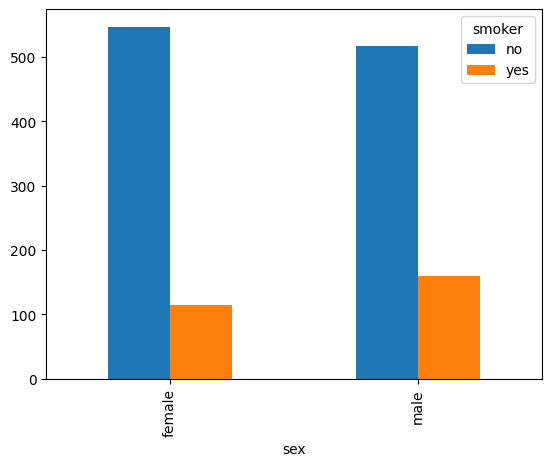

In [8]:
Gender = pd.crosstab(data['sex'],data['smoker'])
print(Gender)
Gender.plot(kind='bar')

## 3. Data Preprocessing


Data should be preprocessed and cleaned to get rid of noisy data.
Preprocessing includes:
 - dealing with missing data
   - remove whole rows (if they are not a lot)
   - infer (e.g., date of birth & age)
   - fill with mean, median, or even 0
 - removing unsued column(s)
 - convert categorical (non numerical) data into numerical
 - normalization: standarize data ranges for all features (e.g., between 0 and 1)



---


#### Removing missing data.

In [9]:
# print how many missing value in each column
data.isnull().sum()

,0
age,0
sex,0
bmi,3
children,0
smoker,0
region,0
charges,0


Drop rows with missing values

In [10]:
# drop rows with missing values
data = data.dropna()
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


#### Convert Categorical columns to numerical

*   convert the sex column from male/female to 0/1.
*   convert the smoker column from no/yes to 0/1.





In [11]:
# define dictionary
gender =  {'male': 0, 'female': 1}
# replace sex column with 0/1
data['sex'] = data['sex'].apply(lambda x: gender[x])
# print head to verify
data.head()

<ipython-input-11-2002edd50773>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sex'] = data['sex'].apply(lambda x: gender[x])


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


And now the smokers column

In [12]:
# define dictionary
smokers = {'no':0, 'yes':1}
# replace smokers column with 0/1
data['smoker'] = data['smoker'].apply(lambda x: smokers[x])
# print head to verify
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


And now the Region Column

In [13]:
# define dictionary
regions = {'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3}
# replace region column with the corresponding values
data['region'] = data['region'].apply(lambda x: regions[x])
# print head to verify
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,0,16884.92400
1,18,0,33.770,1,0,1,1725.55230
2,28,0,33.000,3,0,1,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520


##Normalization



In [14]:
# get the max of each column
data_max = data.max()
data_max

,0
age,64.00000
sex,1.00000
bmi,53.13000
children,5.00000
smoker,1.00000
region,3.00000
charges,63770.42801


In [15]:
# divide each column by its maximum value
data = data.divide(data_max)
data.describe()

,age,sex,bmi,children,smoker,region,charges
count,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000
mean,0.612441,0.495131,0.577102,0.219476,0.205243,0.495381,0.208299
std,0.219491,0.500164,0.114832,0.241145,0.404031,0.368180,0.190041
min,0.281250,0.000000,0.300395,0.000000,0.000000,0.000000,0.017592
25%,0.421875,0.000000,0.495059,0.000000,0.000000,0.333333,0.074365
50%,0.609375,0.000000,0.572181,0.200000,0.000000,0.333333,0.147187
75%,0.796875,1.000000,0.652880,0.400000,0.000000,0.666667,0.262144
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Model Training & Testing



#### Data splits



In [16]:
features = ['age',	'sex',	'bmi',	'children', 'region',	'charges']
X = data[features]

y = data['smoker']

# split dataset in a 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 , random_state=42)


print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1068, 6) (1068,)
(267, 6) (267,)


### Logistic Regression Modeling


In [17]:
# define our regression model
model = LogisticRegression()
# train our model
model.fit(x_train, y_train)

LogisticRegression()

In [18]:
y_pred = model.predict(x_test)
print(y_pred[3])

1.0


In [19]:
print("Not Smoker" if y_pred[3] == 0 else "Smoker")

Smoker


###Evaluation

In [20]:
y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score

accuracy_model_1 = accuracy_score(y_pred, y_test)
precision_model1 = precision_score(y_test, y_pred)


print("Accuracy:", accuracy_model_1,"\nPrecision:",precision_model1,)

Accuracy: 0.898876404494382 
Precision: 0.9523809523809523


## Saving the Model

In [35]:
joblib.dump(model, 'SmokerClassificationModel.pkl')

print("Model saved!")

Model saved!


## Uploading the model to Hugging Face

In [24]:
from huggingface_hub import login
login()

In [32]:
from huggingface_hub import create_repo

repo_name = "Smoker_Classifier_Model"
create_repo(repo_name)


RepoUrl('https://huggingface.co/ShaimaAli1/Smoker_Classifier_Model', endpoint='https://huggingface.co', repo_type='model', repo_id='ShaimaAli1/Smoker_Classifier_Model')

In [33]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj="/content/Smoker_Classifier_Model.ipynb",
    path_in_repo="Smoker_Classifier_Model.pkl",
    repo_id="ShaimaAli1/Smoker_Classifier_Model",
)



Smoker_Classifier_Model.ipynb:   0%|          | 0.00/294k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/ShaimaAli1/Smoker_Classifier_Model/commit/466cdd42ed5b4ae27031fd0812a1d2843c775fa6', commit_message='Upload Smoker_Classifier_Model.pkl with huggingface_hub', commit_description='', oid='466cdd42ed5b4ae27031fd0812a1d2843c775fa6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ShaimaAli1/Smoker_Classifier_Model', endpoint='https://huggingface.co', repo_type='model', repo_id='ShaimaAli1/Smoker_Classifier_Model'), pr_revision=None, pr_num=None)